* 실습 전 런타임 유형 변경 GPU

# 1. CIFAR-10 이란?
캐나다 고등 연구 기관(Canadian Institute For Advanced Research)에서 수집한 이미지 데이터셋입니다.

10개의 클래스(비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭)로 구성된 컬러 이미지 데이터셋입니다.

주로 이미지 분류(Classification) 실습에 사용됩니다.

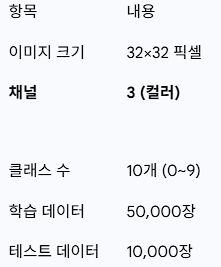

# 2. 모델 아키텍처 (Mini-VGG)

**1번 레이어 : 합성곱 블록 (Convolutional Block)**

입력: (batch_size, 3, 32, 32)

합성곱(in_channels=3, out_channels=64, kernel_size=3, padding=1) + 활성화 함수 ReLU

합성곱(in_channels=64, out_channels=64, kernel_size=3, padding=1) + 활성화 함수 ReLU

맥스풀링(kernel_size=2, stride=2)

출력: (batch_size, 64, 16, 16)

**2번 레이어 : 합성곱 블록 (Convolutional Block)**

입력: (batch_size, 64, 16, 16)

합성곱(in_channels=64, out_channels=128, kernel_size=3, padding=1) + 활성화 함수 ReLU

합성곱(in_channels=128, out_channels=128, kernel_size=3, padding=1) + 활성화 함수 ReLU

맥스풀링(kernel_size=2, stride=2)

출력: (batch_size, 128, 8, 8)

**3번 레이어 : 전결합 블록 (Fully-Connected Block)**

입력: (batch_size, 128, 8, 8)

특성맵 펼치기 (Flatten) → (batch_size, 128 * 8 * 8) 또는 (batch_size, 8192)

전결합층(in_features=8192, out_features=256) + 활성화 함수 ReLU

전결합층(in_features=256, out_features=10)

 출력: (batch_size, 10)

# 3. CIFAR-10 분류 모델 구현하기 (Notebook)

# 기본 세팅

In [5]:
conda install pytorch torchvision -c pytorch


InvalidArchiveError("Error with archive C:\\anaconda\\pkgs\\pytorch-2.11.0-cpu_mkl_py313h1bc36f0_100.conda.  You probably need to delete and re-download or re-create this file.  Message was:\n\nfailed with error: [Errno 2] No such file or directory: 'C:\\\\anaconda\\\\pkgs\\\\pytorch-2.11.0-cpu_mkl_py313h1bc36f0_100\\\\info\\\\test\\\\test\\\\compiled_autograd_skips\\\\TestNestedTensorSubclassCPU.test_op_dim_reduce_ragged_idx_greater_than_1_different_output_shape_mean_transpose_offset_1_keepdim_True_requires_grad_False_components_require_grad_False_cpu_float32'")



Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - pytorch
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Anaconda

  added / updated specs:
    - pytorch
    - torchvision


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    arrow-cpp-23.0.1           |   cpu_hcd2f260_3         7.1 MB
    aws-c-auth-0.9.4           |       h02ab6af_0         118 KB
    aws-c-cal-0.9.13           |       h630b2a1_0          58 KB
    aws-c-common-0.12.6        |       h02ab6af_0         238 KB
    aws-c-compression-0.3.1    |       h02ab6af_3          29 KB
    aws-c-event-stream-0.5.9   |       h02ab6af_0          61 KB
    aws-c-http-0.10.7          |       h02ab6af_0         193 KB
    aws-c-io-0.23.3            |       h02ab6af_0         170 KB
    aws-c-mqtt-0.13.3          |       h02ab6af_1         195 

In [ ]:
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.nn.init as init

# CUDA 사용 설정 /  CUDA : GPU를 이용해 연산을 가속할 수 있도록 설계된 기술
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# GPU 사용 가능일 경우 랜덤 시드 고정
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

#학습 준비

In [ ]:
# 파라미터 설정
learning_rate = 0.001
training_epochs = 15
batch_size = 100

# 데이터셋 정의
# CIFAR-10 데이터는 3채널(RGB)이며, 픽셀 값이 0~1이 아니므로 정규화(Normalize)가 필요합니다.
transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)) # 3개 채널에 대한 정규화
])

cifar10_train = dsets.CIFAR10(root='CIFAR10_data/',
                            train=True,
                            transform=transform, # ⭐⭐빈칸 1⭐⭐: 위에서 정의한 'transform'을 적용해주세요
                            download=True)

cifar10_test = dsets.CIFAR10(root='CIFAR10_data/',
                           train=False,
                           transform=transform, # ⭐⭐빈칸 2⭐⭐: 훈련 데이터와 동일한 'transform'을 적용해주세요
                           download=True)

# 데이터로더를 사용하여 배치 크기 지정
data_loader = torch.utils.data.DataLoader(dataset=cifar10_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

100%|██████████| 170M/170M [00:03<00:00, 43.8MB/s]


# 클래스로 모델 설정

In [ ]:
class MiniVGG(nn.Module):

    def __init__(self):
        super().__init__()

        # === Block 1 ===
        # 배치 크기 × 채널 × 높이(height) × 너비(widht)
        # In: (100, 3, 32, 32)
        # Conv1 -> (100, 64, 32, 32)
        # Conv2 -> (100, 64, 32, 32)
        # Pool  -> (100, 64, 16, 16)
        self.layer1 = nn.Sequential(
            # ⭐⭐빈칸 3⭐⭐: input channel 수를 정해주세요.
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # === Block 2 ===
        # In: (100, 64, 16, 16)
        # Conv1 -> (100, 128, 16, 16)
        # Conv2 -> (100, 128, 16, 16)
        # Pool  -> (100, 128, 8, 8)
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # === Block 3 (Fully-Connected) ===
        # In: (100, 128, 8, 8)
        # Flatten -> (100, 128 * 8 * 8) = (100, 8192)
        # FC1 -> (100, 256)
        # FC2 -> (100, 10)
        self.fc = nn.Sequential(
            # ⭐⭐빈칸 4⭐⭐: layer2의 최종 출력 텐서를 펼쳤을 때의 크기를 in_features로 입력해주세요.
            nn.Linear(in_features=128 * 8 * 8, out_features=256, bias=True),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=10, bias=True)
        )

        # 가중치 초기화
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                init.xavier_normal_(m.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)   # Flatten
        out = self.fc(out)
        return out

#⭐⭐문제⭐⭐


첫번째 층에서 합성곱층과 풀링층의 커널 사이즈와 스트라이드 크기를 각각 작성해주세요.
- 합성곱층
    - 커널 :
    - 스트라이드 :
- 풀링층
  - 커널 :
  - 스트라이드 :

# 모델/비용함수/옵티마이저 정의

In [ ]:
# Mini-VGG 모델 정의
model = MiniVGG().to(device)

# 비용함수 & 옵티마이저
criterion = nn.CrossEntropyLoss().to(device) # Softmax 포함
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 배치 수 확인

In [ ]:
total_batch = len(data_loader)
print(f'총 배치의 수 : {total_batch}')
# 미니 배치 크기를 100으로 했으므로 결국 훈련 데이터는 총 50,000개란 의미

총 배치의 수 : 500


# 모델 훈련

In [ ]:
for epoch in range(training_epochs):
    avg_cost = 0  # 에포크당 평균 비용을 저장하기 위한 변수 초기화

    for X, Y in data_loader:# 미니 배치 단위로 데이터를 꺼내옴. X는 입력 데이터, Y는 레이블
        # 이미지 데이터는 이미 (32x32) 크기를 가지므로, 별도의 reshape 필요 없음
        # 레이블 Y는 원-핫 인코딩이 아닌 정수형 클래스 레이블임
        X = X.to(device)  # 입력 데이터를 연산이 수행될 장치로 이동 (예: GPU)
        Y = Y.to(device)  # 레이블 데이터를 연산이 수행될 장치로 이동 (예: GPU)

        optimizer.zero_grad()  # 옵티마이저의 기울기 초기화
        hypothesis = model(X) # 모델을 통해 예측값(hypothesis)을 계산 (순전파 연산)
        cost = criterion(hypothesis, Y) # 예측값과 실제값 Y 간의 손실(cost) 계산
        cost.backward()  # 역전파 연산을 통해 기울기 계산
        optimizer.step() # 옵티마이저를 통해 파라미터 업데이트

        avg_cost += cost / len(data_loader) # 현재 배치의 비용을 전체 배치 수로 나누어 누적

    # 에포크가 끝날 때마다 평균 비용 출력
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

[Epoch:    1] cost = 1.28798199
[Epoch:    2] cost = 0.802756786
[Epoch:    3] cost = 0.580158651
[Epoch:    4] cost = 0.404373109
[Epoch:    5] cost = 0.25065133
[Epoch:    6] cost = 0.1478827
[Epoch:    7] cost = 0.107844025
[Epoch:    8] cost = 0.0872789249
[Epoch:    9] cost = 0.073193185
[Epoch:   10] cost = 0.0635245666
[Epoch:   11] cost = 0.0682425499
[Epoch:   12] cost = 0.0593394339
[Epoch:   13] cost = 0.0527978949
[Epoch:   14] cost = 0.0462059677
[Epoch:   15] cost = 0.05728155


# 모델 예측

In [ ]:
# 학습을 진행하지 않을 것이므로 torch.no_grad() 사용
with torch.no_grad():
    X_test = cifar10_test.data
    X_test = torch.from_numpy(X_test).float().permute(0, 3, 1, 2).to(device) # (N, H, W, C) -> (N, C, H, W)
    # 테스트 데이터도 훈련 데이터와 동일하게 정규화
    normalize = transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    X_test = normalize(X_test / 255.0) # 0~255 값을 0~1로 스케일링 후 정규화

    Y_test = torch.tensor(cifar10_test.targets).to(device)

    # 모델 예측
    prediction = model(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test

    # 정확도 계산
    accuracy = correct_prediction.float().mean()
    print('Accuracy:', accuracy.item())

Accuracy: 0.7498999834060669


#⭐⭐문제⭐⭐

nn.Conv2d (합성곱 층)에서 사용되는 커널(Kernel)의 주요 역할은 무엇인가요?

- 정답 :수평선, 수직선 등의 경계(Edge)
모서리(Corner)
특정 무늬(Texture)
복잡한 형태(얼굴, 물체의 일부 등)